## Set up

### imports and paths

In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np; import pandas as pd; import math as math; import copy
from scipy.ndimage import gaussian_filter as gaussian_filter; import scipy.stats as stats
import statsmodels.api as sm; lowess = sm.nonparametric.lowess; from skimage import transform

import matplotlib as mpl; import matplotlib.pyplot as plt; import matplotlib.gridspec as gridspec; from matplotlib import cm; from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable #from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Circle; from matplotlib.patches import Rectangle

import os, sys; from glob import glob; from pathlib import Path; import pickle
import tifffile as tfl; from datetime import datetime

#mworks imports
# sys.path.append(Path('..\\mworksbehavior').resolve().as_posix()); 

#local files and shorthand notations for assigning common functions to variable names
sys.path.append(Path('..\\src').resolve().as_posix()); 


import quietcell_select_fxns_all as qcsf
# from mworksbehavior import mwkfiles; from mworksbehavior.imaging import intrinsic as ii; import mworksbehavior as mwb; import mworksbehavior.mwk_io

r_ = np.r_; a_ = np.asarray

In [4]:
# Paths
file_path_root = 'C:\\Users\\Connor\\data-local\\Debugging\\connor2505\\i5309'
 
file_path_suite2p = os.path.join(file_path_root,'suite2p/')

file_path_pre = os.path.join(file_path_root,'240827-i5309-pre')
file_path_pre_pattern = os.path.join(file_path_pre,'patterns/')
file_path_pre_arrays = os.path.join(file_path_root,'npys-pre/')

file_path_post = os.path.join(file_path_root,'240901-i5309')
file_path_post_pattern = os.path.join(file_path_post,'patterns/')
file_path_post_arrays = os.path.join(file_path_root,'npys-post/')

### loads - Be very careful here, it is possible to save / load old versions as you troubleshoot

In [14]:
if True:
    avgTrial2P_pre = np.load(os.path.join(file_path_pre_arrays,'avgTrial2P_pre.npy'))
    df_2P_pre = np.load(os.path.join(file_path_pre_arrays,'df_2P_pre.npy'))
    avgPrestim2P_pre = np.load(os.path.join(file_path_pre_arrays,'avgPrestim2P_pre.npy'))
    trial_dfoFsmooth2P_pre = np.load(os.path.join(file_path_pre_arrays,'trial_dfoFsmooth2P_pre.npy'))
    avgTrialV_pre = np.load(os.path.join(file_path_pre_arrays,'avgTrialV_pre.npy'))
    df_V_pre = np.load(os.path.join(file_path_pre_arrays,'df_V_pre.npy'))
    avgPrestimV_pre = np.load(os.path.join(file_path_pre_arrays,'avgPrestimV_pre.npy'))
    trial_dfoFsmoothV_pre = np.load(os.path.join(file_path_pre_arrays,'trial_dfoFsmoothV_pre.npy'))

    trial_ftrace_pre = np.load(os.path.join(file_path_pre_arrays,'trial_ftrace_pre_lseg.npy'))
    avgTrial_cell_pre = np.load(os.path.join(file_path_pre_arrays,'avgTrial_cell_pre_lseg.npy'))
    trial_dfoFtrace_pre = np.load(os.path.join(file_path_pre_arrays,'trial_dfoFtrace_pre_lseg.npy'))
    df2P_cell_pre = np.load(os.path.join(file_path_pre_arrays,'df2P_cell_pre_lseg.npy'))
    dfoF2P_cell_pre = np.load(os.path.join(file_path_pre_arrays,'dfoF2P_cell_pre_lseg.npy'))
    dfV_cell_pre = np.load(os.path.join(file_path_pre_arrays,'dfV_cell_pre_lseg.npy'))
    dfoFV_cell_pre = np.load(os.path.join(file_path_pre_arrays,'dfoFV_cell_pre_lseg.npy'))
    dFoF_map_maskV_pre = np.load(os.path.join(file_path_pre_arrays,'dFoF_map_maskV_pre_lseg.npy'))
    dFoF_map_mask2P_pre = np.load(os.path.join(file_path_pre_arrays,'dFoF_map_mask2P_pre_lseg.npy'))

In [15]:
if True:
    avgTrial2P_post = np.load(os.path.join(file_path_post_arrays,'avgTrial2P_post.npy'))
    df_2P_post  = np.load(os.path.join(file_path_post_arrays,'df_2P_post.npy'))
    avgPrestim2P_post = np.load(os.path.join(file_path_post_arrays,'avgPrestim2P_post.npy'))
    trial_dfoFsmooth2P_post = np.load(os.path.join(file_path_post_arrays,'trial_dfoFsmooth2P_post.npy'))
    avgTrialV_post = np.load(os.path.join(file_path_post_arrays,'avgTrialV_post.npy'))
    df_V_post = np.load(os.path.join(file_path_post_arrays,'df_V_post.npy'))
    avgPrestimV_post = np.load(os.path.join(file_path_post_arrays,'avgPrestimV_post.npy'))
    trial_dfoFsmoothV_post = np.load(os.path.join(file_path_post_arrays,'trial_dfoFsmoothV_post.npy'))
    
    trial_ftrace_post = np.load(os.path.join(file_path_post_arrays,'trial_ftrace_post_lseg.npy'))
    avgTrial_cell_post = np.load(os.path.join(file_path_post_arrays,'avgTrial_cell_post_lseg.npy'))
    trial_dfoFtrace_post = np.load(os.path.join(file_path_post_arrays,'trial_dfoFtrace_post_lseg.npy'))
    df2P_cell_post = np.load(os.path.join(file_path_post_arrays,'df2P_cell_post_lseg.npy'))
    dfoF2P_cell_post = np.load(os.path.join(file_path_post_arrays,'dfoF2P_cell_post_lseg.npy'))
    dfV_cell_post = np.load(os.path.join(file_path_post_arrays,'dfV_cell_post_lseg.npy'))
    dfoFV_cell_post = np.load(os.path.join(file_path_post_arrays,'dfoFV_cell_post_lseg.npy'))
    dFoF_map_maskV_post = np.load(os.path.join(file_path_post_arrays,'dFoF_map_maskV_post_lseg.npy'))
    dFoF_map_mask2P_post = np.load(os.path.join(file_path_post_arrays,'dFoF_map_mask2P_post_lseg.npy'))

In [5]:
if False: 
    if not os.path.exists(file_path_pre_arrays):
        os.makedirs(file_path_pre_arrays, exist_ok=True)
    if not os.path.exists(file_path_post_arrays):
        os.makedirs(file_path_post_arrays, exist_ok=True)
    np.save(os.path.join(file_path_pre_arrays,'avgTrial2P_pre.npy'), avgTrial2P_pre)
    np.save(os.path.join(file_path_pre_arrays,'df_2P_pre.npy'), df_2P_pre)
    np.save(os.path.join(file_path_pre_arrays,'avgPrestim2P_pre.npy'), avgPrestim2P_pre)
    np.save(os.path.join(file_path_pre_arrays,'trial_dfoFsmooth2P_pre.npy'), trial_dfoFsmooth2P_pre)
    np.save(os.path.join(file_path_pre_arrays,'avgTrialV_pre.npy'), avgTrialV_pre)
    np.save(os.path.join(file_path_pre_arrays,'df_V_pre.npy'), df_V_pre)
    np.save(os.path.join(file_path_pre_arrays,'avgPrestimV_pre.npy'), avgPrestimV_pre)
    np.save(os.path.join(file_path_pre_arrays,'trial_dfoFsmoothV_pre.npy'), trial_dfoFsmoothV_pre)

    np.save(os.path.join(file_path_post_arrays,'avgTrial2P_post.npy'), avgTrial2P_post)
    np.save(os.path.join(file_path_post_arrays,'df_2P_post.npy'), df_2P_post)
    np.save(os.path.join(file_path_post_arrays,'avgPrestim2P_post.npy'), avgPrestim2P_post)
    np.save(os.path.join(file_path_post_arrays,'trial_dfoFsmooth2P_post.npy'), trial_dfoFsmooth2P_post)
    np.save(os.path.join(file_path_post_arrays,'avgTrialV_post.npy'), avgTrialV_post)
    np.save(os.path.join(file_path_post_arrays,'df_V_post.npy'), df_V_post)
    np.save(os.path.join(file_path_post_arrays,'avgPrestimV_post.npy'), avgPrestimV_post)
    np.save(os.path.join(file_path_post_arrays,'trial_dfoFsmoothV_post.npy'), trial_dfoFsmoothV_post)

    np.save(os.path.join(file_path_post_arrays,'trial_ftrace_post_lseg.npy'), trial_ftrace_post)        
    np.save(os.path.join(file_path_post_arrays,'avgTrial_cell_post_lseg.npy'), avgTrial_cell_post)
    np.save(os.path.join(file_path_post_arrays,'trial_dfoFtrace_post_lseg.npy'), trial_dfoFtrace_post)
    np.save(os.path.join(file_path_post_arrays,'df2P_cell_post_lseg.npy'), df2P_cell_post)
    np.save(os.path.join(file_path_post_arrays,'dfoF2P_cell_post_lseg.npy'), dfoF2P_cell_post)
    np.save(os.path.join(file_path_post_arrays,'dfV_cell_post_lseg.npy'), dfV_cell_post)
    np.save(os.path.join(file_path_post_arrays,'dfoFV_cell_post_lseg.npy'), dfoFV_cell_post)
    np.save(os.path.join(file_path_post_arrays,'dFoF_map_cell_masksV_post_lseg.npy'),dFoF_map_cell_masksV_post)
    np.save(os.path.join(file_path_post_arrays,'dFoF_map_cell_masks2P_post_lseg.npy'),dFoF_map_cell_masks2P_post)
    np.save(os.path.join(file_path_post_arrays,'dFoF_map_mask2P_post_lseg.npy'),dFoF_map_mask2P_post) #longitudinally segmented
    np.save(os.path.join(file_path_post_arrays,'dFoF_map_maskV_post_lseg.npy'),dFoF_map_maskV_post)

    np.save(os.path.join(file_path_pre_arrays,'trial_ftrace_pre_lseg.npy'), trial_ftrace_pre)
    np.save(os.path.join(file_path_pre_arrays,'avgTrial_cell_pre_lseg.npy'), avgTrial_cell_pre)
    np.save(os.path.join(file_path_pre_arrays,'trial_dfoFtrace_pre_lseg.npy'), trial_dfoFtrace_pre)
    np.save(os.path.join(file_path_pre_arrays,'df2P_cell_pre_lseg.npy'), df2P_cell_pre)
    np.save(os.path.join(file_path_pre_arrays,'dfoF2P_cell_pre_lseg.npy'), dfoF2P_cell_pre)
    np.save(os.path.join(file_path_pre_arrays,'dfV_cell_pre_lseg.npy'), dfV_cell_pre)
    np.save(os.path.join(file_path_pre_arrays,'dfoFV_cell_pre_lseg.npy'), dfoFV_cell_pre)
    np.save(os.path.join(file_path_pre_arrays,'dFoF_map_cell_masksV_pre_lseg.npy'),dFoF_map_cell_masksV_pre)
    np.save(os.path.join(file_path_pre_arrays,'dFoF_map_cell_masks2P_pre_lseg.npy'),dFoF_map_cell_masks2P_pre)
    np.save(os.path.join(file_path_pre_arrays,'dFoF_map_mask2P_pre_lseg.npy'),dFoF_map_mask2P_pre) #longitudinally segmented
    np.save(os.path.join(file_path_pre_arrays,'dFoF_map_maskV_pre_lseg.npy'),dFoF_map_maskV_pre)
    #np.save(os.path.join(file_path_pre_arrays,'trial_parsed_frames_pre.npy'), frames_pre) # these massive npy arrays can be saved if we need
    #np.save(os.path.join(file_path_post_arrays,'trial_parsed_frames_post.npy'), frames_post) # these massive npy arrays can be saved if we need

### final set up

In [3]:
F = np.load(os.path.join(file_path_root,'suite2p/suite2p/plane0/F.npy'))

isCell = np.load(os.path.join(file_path_root,'suite2p/suite2p/plane0/isCell.npy'))

In [4]:
exp_params = pickle.load(open(os.path.join(file_path_suite2p,'expt_params.pkl'),'rb')); #print('\npre_params)

In [5]:
#exp_params#['nCell'] = 352
nCell = exp_params['nCell']; print(nCell)
br = exp_params['baseline_frame_range']

266


In [6]:
# CMP: changed paths for files 
im_pre = tfl.imread(os.path.join(file_path_pre,'imageFrames-mc-pre.tif'))[:]; print('pre stim:',im_pre.shape, end='; ')
im_post = tfl.imread(os.path.join(file_path_post,'imageFrames-mc-post.tif'))[:]; print('post stim:',im_post.shape, end='; ')
im_aip_post = np.mean(im_post,axis=0)#np.concatenate((avgPrestimV_post,avgPrestim2P_post)),axis=0)
im_aip_pre = np.mean(im_pre,axis=0)#np.concatenate((avgPrestimV_pre,avgPrestim2P_pre)),axis=0)
md = datetime.now().date()

pre stim: (67200, 256, 256); post stim: (67200, 256, 256); 

In [17]:
pat_names_pre = ['pattern1Coor.csv','pattern2Coor.csv','pattern3Coor.csv', 'pattern4Coor.csv', 'pattern5Coor.csv','pattern6Coor.csv','pattern7Coor.csv','pattern8Coor.csv', 'pattern9Coor.csv','pattern10Coor.csv']
pat_names_post = ['pattern1Coor.csv','pattern2Coor.csv','pattern3Coor.csv', 'pattern4Coor.csv', 'pattern5Coor.csv','pattern6Coor.csv','pattern7Coor.csv','pattern8Coor.csv', 'pattern9Coor.csv','pattern10Coor.csv']

titles = ['Pattern 1','Pattern 2','Pattern 3','Pattern 4','Pattern 5','Pattern 6','Pattern 7','Pattern 8','Pattern 9','Pattern 10']

iTrialVis=[0,1,2,3,4,5]
iTrial2P=[6,7,8,9,10,11,12,13,14,15]

## Coords and fov

### coords

In [ ]:
# get cells coords and stim coords - pre
with qcsf.analysis_2p_general(file_path=file_path_suite2p,expt_params=exp_params) as q2pg:
    cell_masks = q2pg.generate_cell_masks_suite2p(file_path_suite2p)
    cell_coords,pattern_coords1,conversion_factor = q2pg.calculate_cell_pattern_coords(file_path_pre_pattern,cell_masks,csv_pattern_filename=pat_names_pre[0])
    cell_coords,pattern_coords2,conversion_factor = q2pg.calculate_cell_pattern_coords(file_path_pre_pattern,cell_masks,csv_pattern_filename=pat_names_pre[1])
    cell_coords,pattern_coords3,conversion_factor = q2pg.calculate_cell_pattern_coords(file_path_pre_pattern,cell_masks,csv_pattern_filename=pat_names_pre[2])
    cell_coords,pattern_coords4,conversion_factor = q2pg.calculate_cell_pattern_coords(file_path_pre_pattern,cell_masks,csv_pattern_filename=pat_names_pre[3])
    cell_coords,pattern_coords5,conversion_factor = q2pg.calculate_cell_pattern_coords(file_path_pre_pattern,cell_masks,csv_pattern_filename=pat_names_pre[4])
    cell_coords,pattern_coords6,conversion_factor = q2pg.calculate_cell_pattern_coords(file_path_pre_pattern,cell_masks,csv_pattern_filename=pat_names_pre[5])
    cell_coords,pattern_coords7,conversion_factor = q2pg.calculate_cell_pattern_coords(file_path_pre_pattern,cell_masks,csv_pattern_filename=pat_names_pre[6])
    cell_coords,pattern_coords8,conversion_factor = q2pg.calculate_cell_pattern_coords(file_path_pre_pattern,cell_masks,csv_pattern_filename=pat_names_pre[7])
    cell_coords,pattern_coords9,conversion_factor = q2pg.calculate_cell_pattern_coords(file_path_pre_pattern,cell_masks,csv_pattern_filename=pat_names_pre[8])
    cell_coords,pattern_coords10,conversion_factor = q2pg.calculate_cell_pattern_coords(file_path_pre_pattern,cell_masks,csv_pattern_filename=pat_names_pre[9])

    
    stim_iC1,nostim_iC1,all_iC1 = q2pg.label_stimulated_cells(cell_coords,pattern_coords1,radius_microns=25) #0.5 pix/um 2x; 0.616 pix/um 2.5x
    stim_iC2,nostim_iC2,all_iC2 = q2pg.label_stimulated_cells(cell_coords,pattern_coords2,radius_microns=25) #0.5 pix/um 2x; 0.616 pix/um 2.5x
    stim_iC3,nostim_iC3,all_iC3 = q2pg.label_stimulated_cells(cell_coords,pattern_coords3,radius_microns=25) #0.5 pix/um 2x; 0.616 pix/um 2.5x
    stim_iC4,nostim_iC4,all_iC4 = q2pg.label_stimulated_cells(cell_coords,pattern_coords4,radius_microns=25) #0.5 pix/um 2x; 0.616 pix/um 2.5x
    stim_iC5,nostim_iC5,all_iC5 = q2pg.label_stimulated_cells(cell_coords,pattern_coords5,radius_microns=25) #0.5 pix/um 2x; 0.616 pix/um 2.5x
    stim_iC6,nostim_iC6,all_iC6 = q2pg.label_stimulated_cells(cell_coords,pattern_coords6,radius_microns=25) #0.5 pix/um 2x; 0.616 pix/um 2.5x
    stim_iC7,nostim_iC7,all_iC7 = q2pg.label_stimulated_cells(cell_coords,pattern_coords7,radius_microns=25) #0.5 pix/um 2x; 0.616 pix/um 2.5x
    stim_iC8,nostim_iC8,all_iC8 = q2pg.label_stimulated_cells(cell_coords,pattern_coords8,radius_microns=25) #0.5 pix/um 2x; 0.616 pix/um 2.5x
    stim_iC9,nostim_iC9,all_iC9 = q2pg.label_stimulated_cells(cell_coords,pattern_coords9,radius_microns=25) #0.5 pix/um 2x; 0.616 pix/um 2.5x
    stim_iC10,nostim_iC10,all_iC10 = q2pg.label_stimulated_cells(cell_coords,pattern_coords10,radius_microns=25) #0.5 pix/um 2x; 0.616 pix/um 2.5x

    
    
pattern_coords_all = np.stack((pattern_coords1,pattern_coords2,pattern_coords3,pattern_coords4,pattern_coords5,pattern_coords6,pattern_coords7,pattern_coords8,pattern_coords9,pattern_coords10))
pattern_coords_all_flat = pattern_coords_all.reshape(-1, pattern_coords_all.shape[-1])
stim_iC = np.concatenate((stim_iC1,stim_iC2,stim_iC3,stim_iC4,stim_iC5,stim_iC6,stim_iC7,stim_iC8,stim_iC9,stim_iC10))
stim_iC = np.unique(stim_iC)
print("how many stimulated cells?", len(stim_iC))
print("how many stimulated spots?", len(pattern_coords_all_flat))
print('Trial-averaged dF/F response map completed.')

In [9]:
with qcsf.analysis_2p_general(file_path=file_path_suite2p,expt_params=exp_params) as q2pg:
    cell_coords,pattern_coords_manip,conversion_factor = q2pg.calculate_cell_pattern_coords(file_path_root,cell_masks,csv_pattern_filename='quiet.csv')
    stim_iC_manip,nostim_iC,all_iC = q2pg.label_stimulated_cells(cell_coords,pattern_coords_manip,radius_microns=10) #0.5 pix/um 2x; 0.616 pix/um 2.5x
    stim_iC_manip12,nostim_iC,all_iC = q2pg.label_stimulated_cells(cell_coords,pattern_coords_manip,radius_microns=12) #0.5 pix/um 2x; 0.616 pix/um 2.5x
    stim_iC_35,ctrl_iC,all_iC = q2pg.label_stimulated_cells(cell_coords,pattern_coords_manip,radius_microns=35) #0.5 pix/um 2x; 0.616 pix/um 2.5x

print("how many stimulated cells?", len(stim_iC_manip))
print("how many stimulated spots?", len(pattern_coords_manip))

zoom = 2.5. Finding cell IDs within direct stimulation radius... Stimulated cell IDs found.
Finding cell IDs within direct stimulation radius... Stimulated cell IDs found.
Finding cell IDs within direct stimulation radius... Stimulated cell IDs found.
how many stimulated cells? 22
how many stimulated spots? 15


In [4]:
if False: # don't need to resave everytime, but use this to play around for troubleshooting
    np.save(os.path.join(file_path_pre_arrays,'stim_iC_manip10.npy'), stim_iC_manip) 
    np.save(os.path.join(file_path_pre_arrays,'stim_iC_manip12.npy'), stim_iC_manip12)
    np.save(os.path.join(file_path_pre_arrays,'ctrl_iC.npy'), ctrl_iC)  

### fov

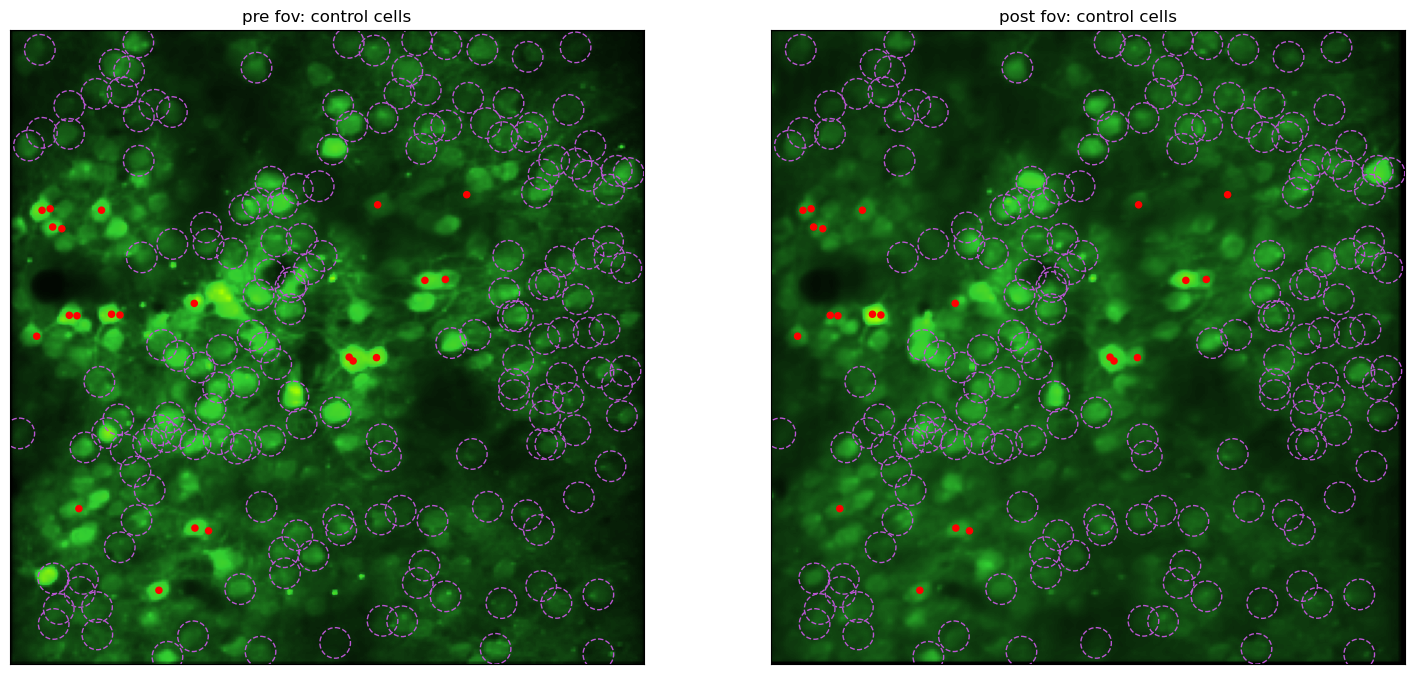

In [49]:
# CMP: Plotting pre and post control cells 

# Pulling control coordinates: 
ctrl_coords = cell_coords[ctrl_iC]

shift_y = 0; shift_x = 0
cmap1 = LinearSegmentedColormap.from_list(name='mycmap',colors=[(0,'#000000'),(0.28, '#32CD32'),(1,'#AAFF00')])

fig,axes = plt.subplots(1,2,figsize=(18,20))

axes[0].imshow(im_aip_pre, cmap=cmap1);axPat.axis('off'); cell_iter = 0
for coords in ctrl_coords:
    axes[0].add_patch( Circle((coords[0]+shift_x,coords[1]+shift_y),radius=10*conversion_factor,fill=False,ec='mediumorchid',ls='--',lw=1,alpha=1) )
    axes[0].set_title('pre fov: control cells')
    axes[0].set_xticks([],"")
    axes[0].set_yticks([],"")
    
for coords in cell_coords[stim_iC_manip]:
    axes[0].add_patch( Circle((coords[0]+shift_x,coords[1]+shift_y),radius=2*conversion_factor,fill=True,color='red',alpha=1) )
    
axes[1].imshow(im_aip_post, cmap=cmap1);axPat.axis('off'); cell_iter = 0
for coords in ctrl_coords:
    axes[1].add_patch( Circle((coords[0]+shift_x,coords[1]+shift_y),radius=10*conversion_factor,fill=False,ec='mediumorchid',ls='--',lw=1,alpha=1) )
    axes[1].set_title('post fov: control cells')
    axes[1].set_xticks([],"")
    axes[1].set_yticks([],"")
    
for coords in cell_coords[stim_iC_manip]:
    axes[1].add_patch( Circle((coords[0]+shift_x,coords[1]+shift_y),radius=2*conversion_factor,fill=True,color= 'red',alpha=1) )

NameError: name 'pattern_coords_all_flat' is not defined

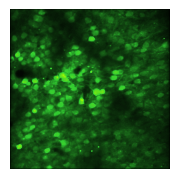

In [19]:
shift_y = 0; shift_x = 0
cmap1 = LinearSegmentedColormap.from_list(name='mycmap',colors=[(0,'#000000'),(0.28, '#32CD32'),(1,'#AAFF00')])


fig = plt.figure(figsize=(7,10))
axPat = fig.add_subplot(331); axPat.imshow(im_aip_pre, cmap=cmap1);axPat.axis('off'); cell_iter = 0
for coords in pattern_coords_all_flat:
    axPat.add_patch( Circle((coords[0]+shift_x,coords[1]+shift_y),radius=10*conversion_factor,fill=False,ec='mediumorchid',ls='--',lw=1,alpha=1) )
    axPat.set_title('pre fov: all opto cells')
ax0 = fig.add_subplot(332); ax0.imshow(im_aip_pre, cmap=cmap1);ax0.axis('off'); cell_iter = 0
for coords in cell_coords[stim_iC_manip]:    
    ax0.add_patch( Circle((coords[0]+shift_x,coords[1]+shift_y),radius=2*conversion_factor,fill=True,ec='orange',ls='solid',lw=2,alpha=1) )
    ax0.text(coords[0]+4,coords[1]+4,stim_iC_manip[cell_iter],fontsize=10,fontweight="bold",c='white'); cell_iter=cell_iter+1
    ax0.set_title('pre fov: trained labeled')
ax1 = fig.add_subplot(333); ax1.imshow(im_aip_post, cmap=cmap1); ax1.axis('off'); cell_iter = 0
for coords in cell_coords[stim_iC_manip]:    
    ax1.add_patch( Circle((coords[0]+shift_x,coords[1]+shift_y),radius=2*conversion_factor,fill=True,ec='orange',ls='solid',lw=2,alpha=1) )
    ax1.text(coords[0]+4,coords[1]+4,stim_iC_manip[cell_iter],fontsize=10,fontweight="bold",c='white'); cell_iter=cell_iter+1
    ax1.set_title('post fov: trained labeled')
plt.tight_layout()

In [ ]:
# Plotting

NameError: name 'cmap2' is not defined

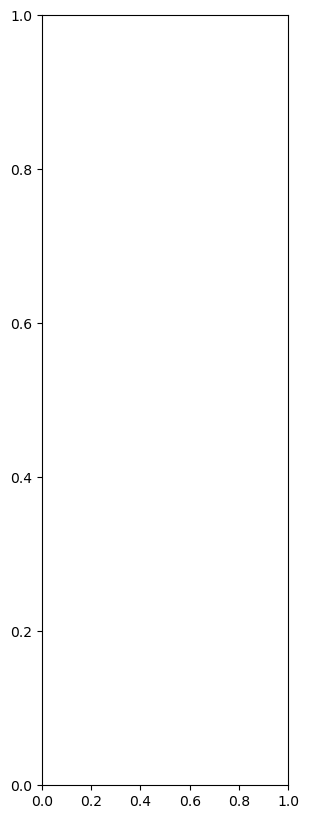

In [26]:
# this is to zoom in to make sure things are REALLY aligned

fig = plt.figure(figsize=(7,10))
x = 190; y = 110
ax0 = fig.add_subplot(121); ax0.imshow(im_aip_pre[x:x+20,y:y+20], cmap=cmap2);ax0.axis('off')
ax1 = fig.add_subplot(122); ax1.imshow(im_aip_post[x:x+20,y:y+20], cmap=cmap2); ax1.axis('off')
plt.tight_layout()

## parse and dfof

### MWorks sort and get frame dfof

In [ ]:
with qcsf.analysis_vis_and_other(file_path=os.path.join(file_path_pre,'stimPre/'),vis_oth_params=exp_params) as qa2p:
        mwf_pre,dd2_pre = qa2p.load_mwk_output(os.path.join(file_path_pre,'stimPre/'))
        levelFrDir_pre, frames_pre= qa2p.parse_trials_mwk(im_pre,im_aip_pre,mwf_pre)

with qcsf.analysis_vis_and_other(file_path=os.path.join(file_path_post,'stimPost/'),vis_oth_params=exp_params) as qa2p:
        mwf_post,dd2_post = qa2p.load_mwk_output(os.path.join(file_path_post,'stimPost/'))
        levelFrDir_post, frames_post = qa2p.parse_trials_mwk(im_post,im_aip_post,mwf_post)
print("done at" , datetime.now().time())

In [12]:
with qcsf.analysis_vis_and_other(file_path=file_path_root,vis_oth_params=exp_params) as qa2p:
        avgTrial2P_pre, df_2P_pre, dfoF_2P_pre,dfoFsmooth_2P_pre, avgPrestim2P_pre, trial_dfoFsmooth2P_pre = qa2p.dfof_pre_2P(frames_pre,iTrial2P,nCutFrs2P=7,nRespFr=6)
        avgTrial2P_post, df_2P_post, dfoF_2P_post,dfoFsmooth_2P_post, avgPrestim2P_post, trial_dfoFsmooth2P_post = qa2p.dfof_pre_2P(frames_post,iTrial2P,nCutFrs2P=7,nRespFr=6)
        
        avgTrialV_pre, df_V_pre, dfoFsmooth_V_pre, avgPrestimV_pre, trial_dfoFsmoothV_pre = qa2p.dfof_pre_vis(frames_pre,iTrialVis)
        avgTrialV_post, df_V_post, dfoFsmooth_V_post, avgPrestimV_post, trial_dfoFsmoothV_post = qa2p.dfof_pre_vis(frames_post,iTrialVis)
        
aip_preStim = np.mean(np.concatenate((avgPrestimV_pre,avgPrestim2P_pre,avgPrestimV_post,avgPrestim2P_post)),axis=0)
print("done at" , datetime.now())

NameError: name 'frames_pre' is not defined

### dfof

In [ ]:
with qcsf.analysis_2p_general(file_path=file_path_pre,expt_params=exp_params) as qapg:
    F = qapg.generate_dfof_cell_traces_suite2p(file_path_suite2p,mwf_pre,multipleDataSetMultiplier=2) #How many datasets re concatenated? They must be all the same length for this input.

F_post =  F[:, :int(F.shape[1]/2)]
F_pre = F[:, int(F.shape[1]/2):]
with qcsf.analysis_vis_and_other(file_path=file_path_pre,vis_oth_params=exp_params) as qa2p:
    trial_ftrace_pre = qa2p.reshape_celltrace_by_mwk_levels(F_pre,mwf_pre)
with qcsf.analysis_vis_and_other(file_path=file_path_post,vis_oth_params=exp_params) as qa2p:
    trial_ftrace_post = qa2p.reshape_celltrace_by_mwk_levels(F_post,mwf_post)
print("done at" , datetime.now().time())

/Users/friedmanng/Repositories/analysisImaging2024/250128-ngf-learningRule/develop/learningRule/src/quietcell_select_fxns_all.py:1016: RuntimeWarning: All-NaN slice encountered
  dFoF_map_mask = np.nanmax(dFoF_map_cell_masks,axis=0)


Generating single frame trial-averaged dF/F response map...
Trial-averaged dF/F response map for cell masks completed.

Generating single frame trial-averaged dF/F response map...
Trial-averaged dF/F response map for cell masks completed.

Generating single frame trial-averaged dF/F response map...
Trial-averaged dF/F response map for cell masks completed.

Generating single frame trial-averaged dF/F response map...


/Users/friedmanng/Repositories/analysisImaging2024/250128-ngf-learningRule/develop/learningRule/src/quietcell_select_fxns_all.py:1037: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=[12,9])


Trial-averaged dF/F response map for cell masks completed.

done at 07:42:20.015027


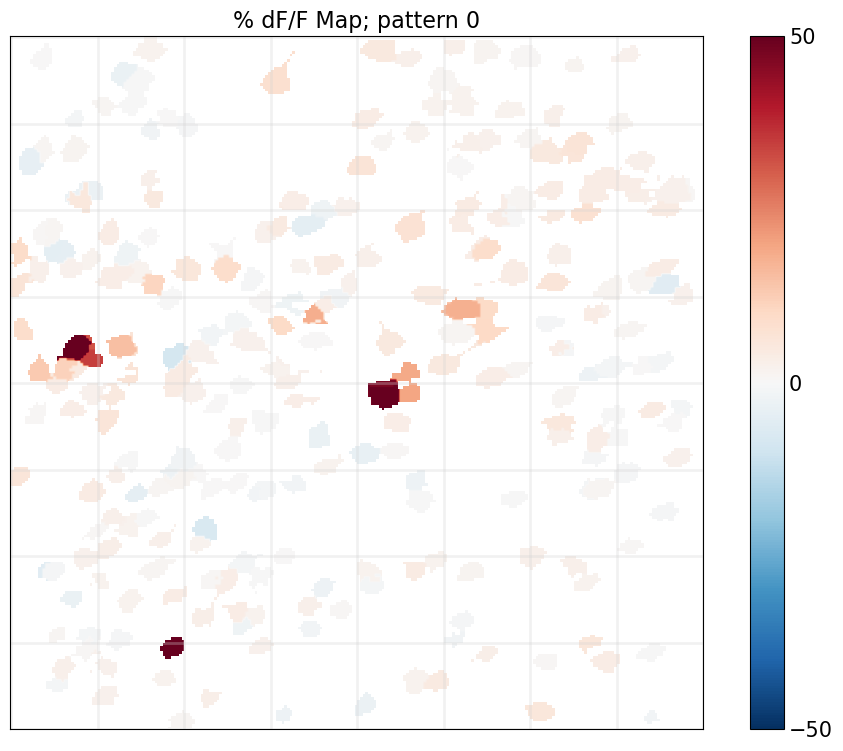

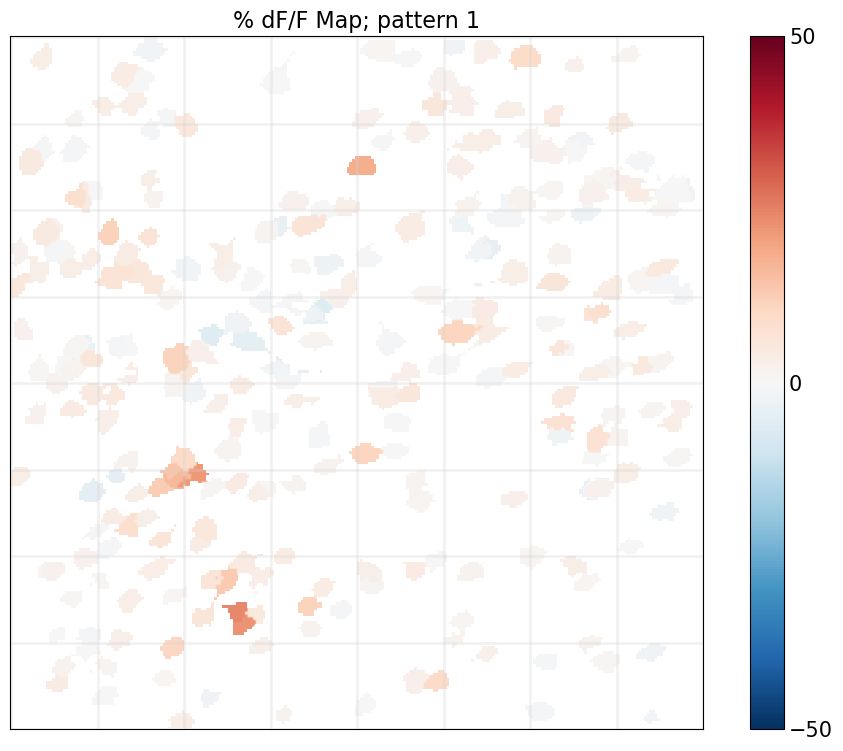

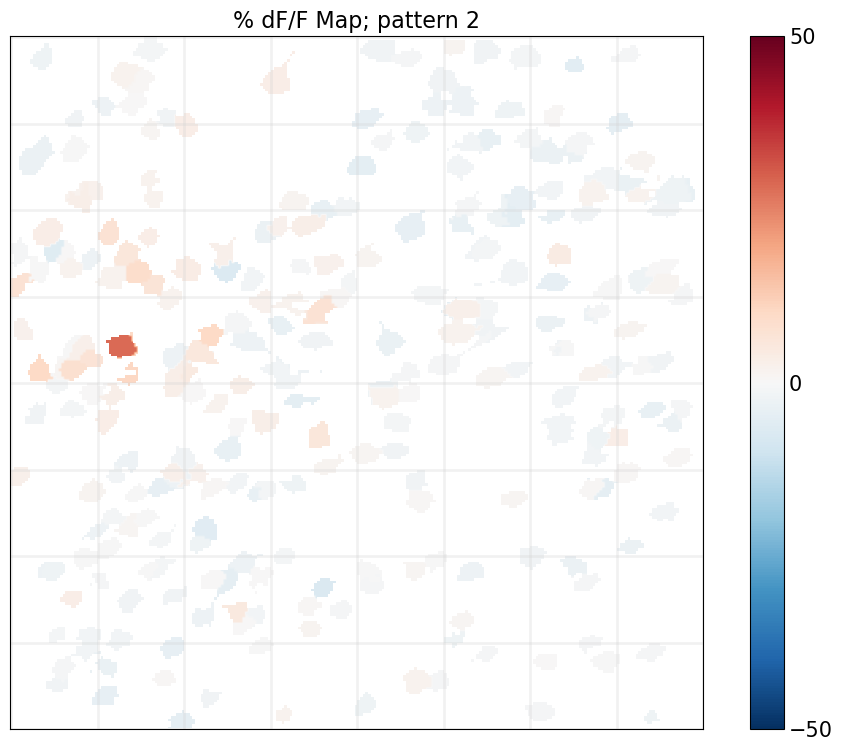

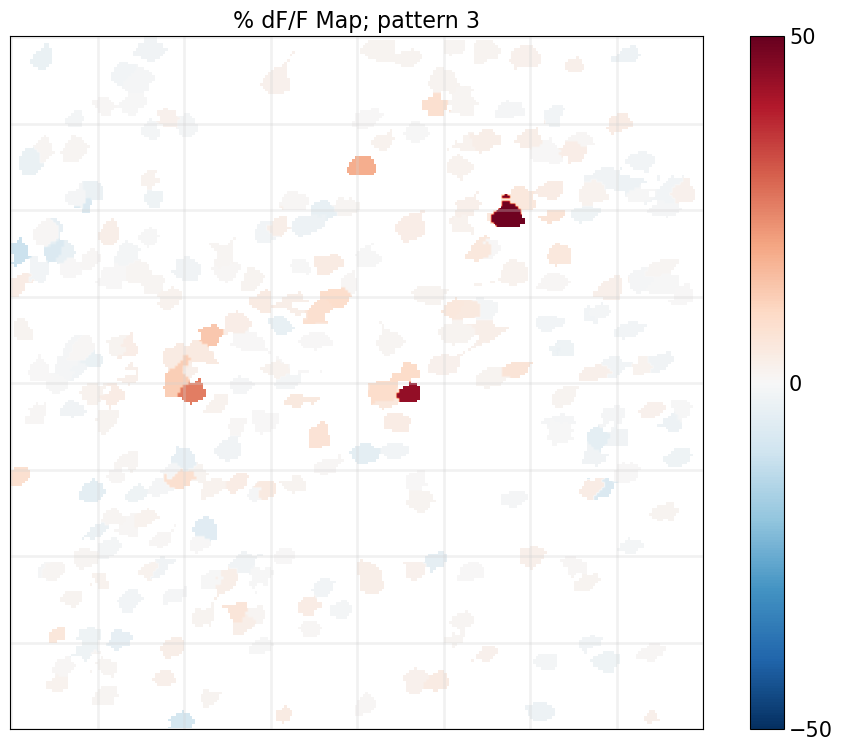

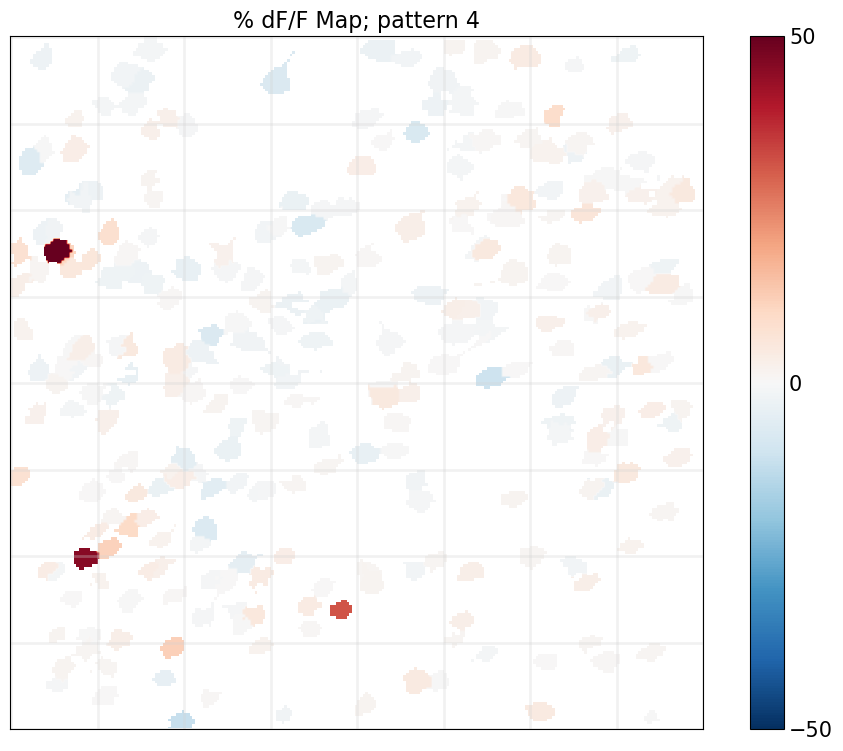

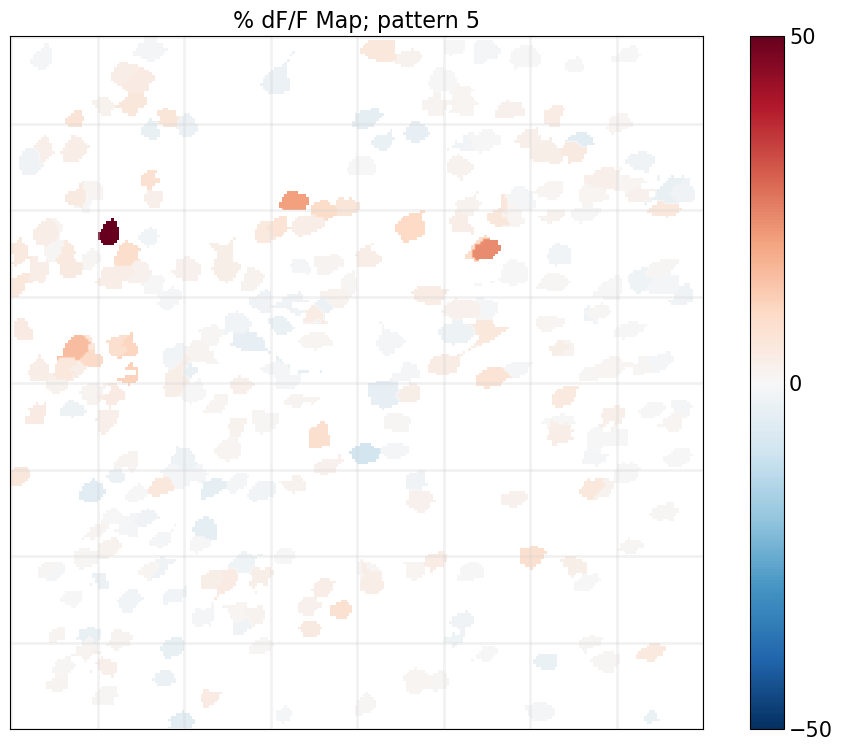

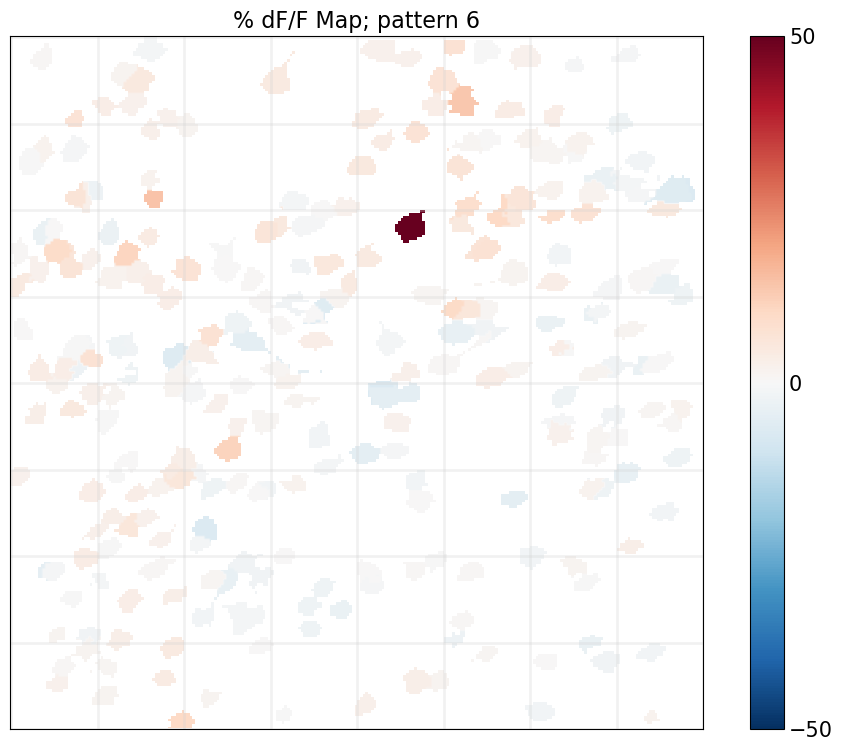

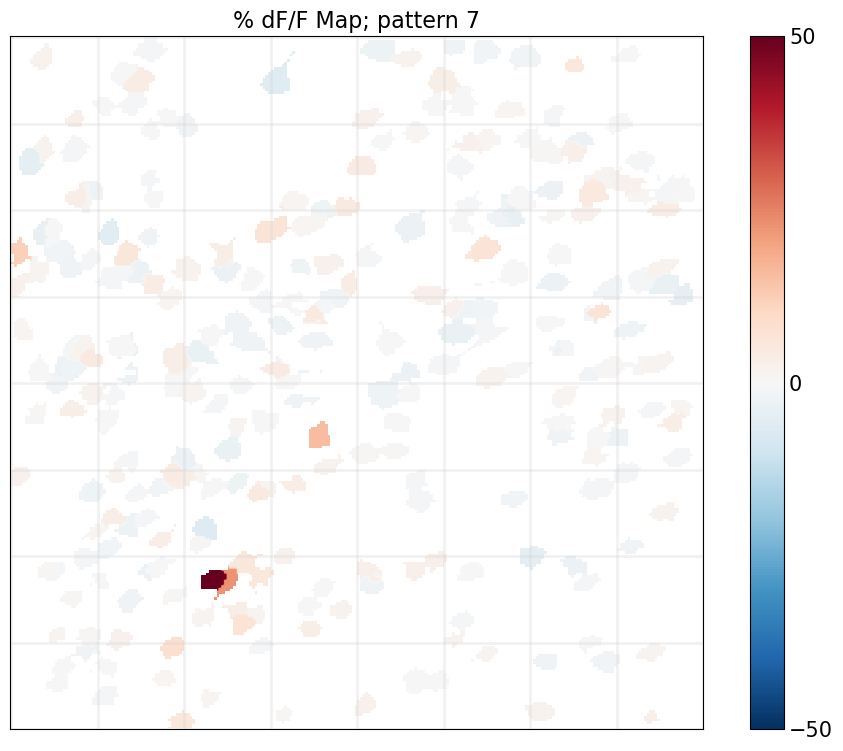

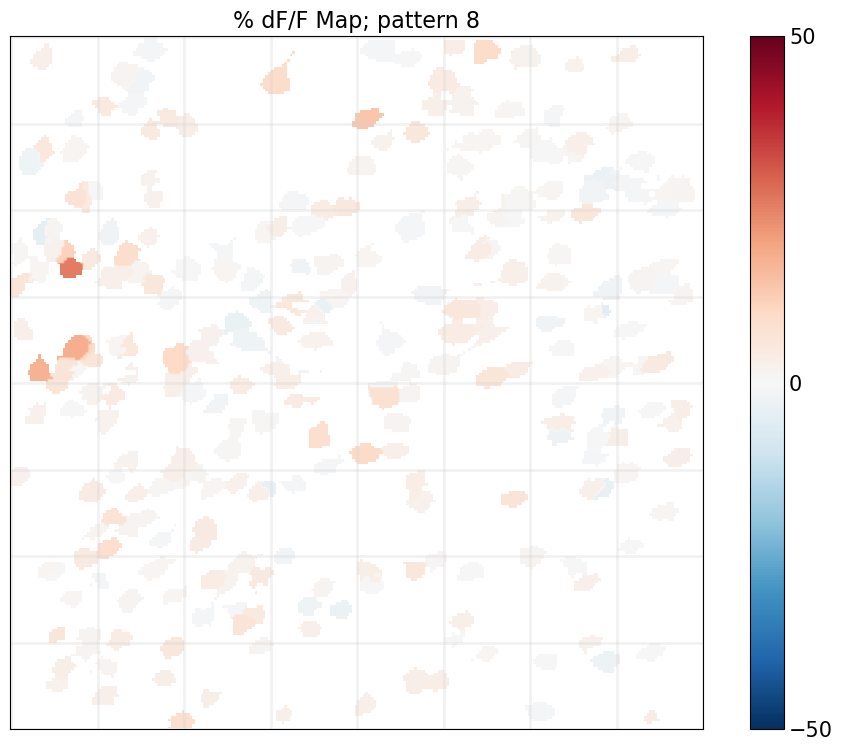

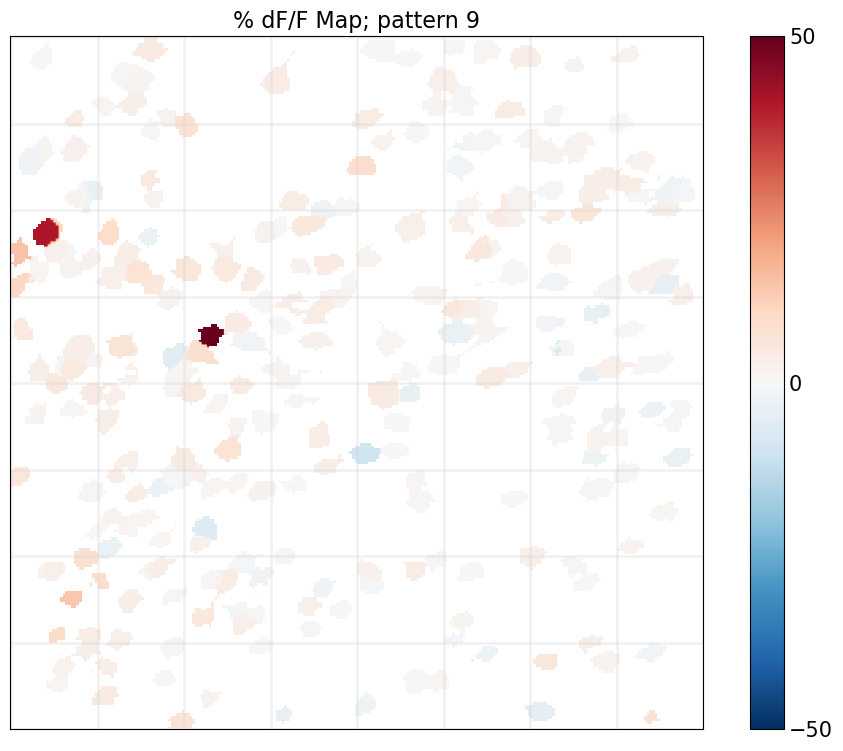

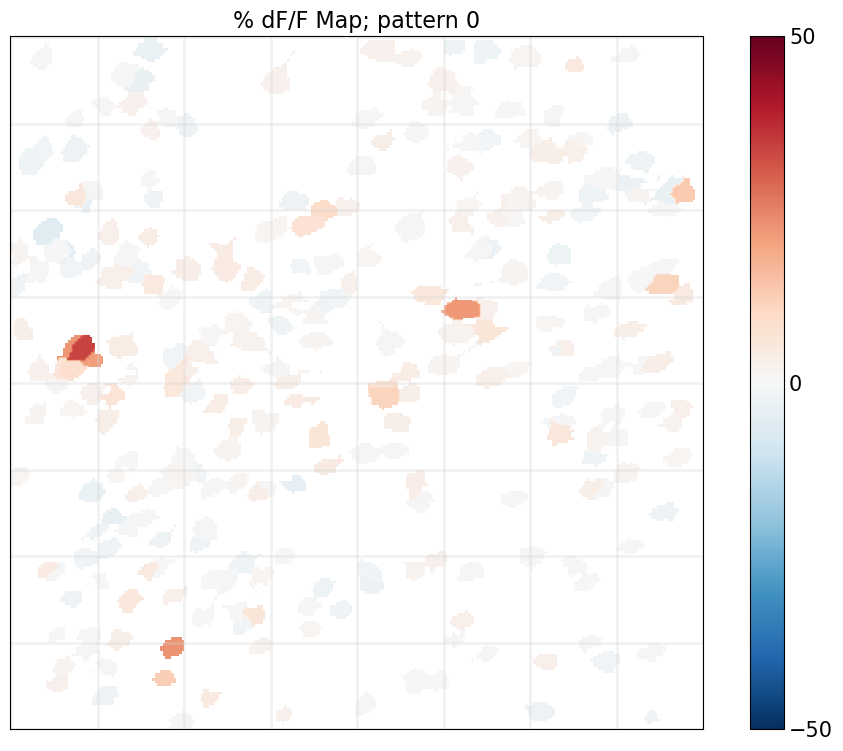

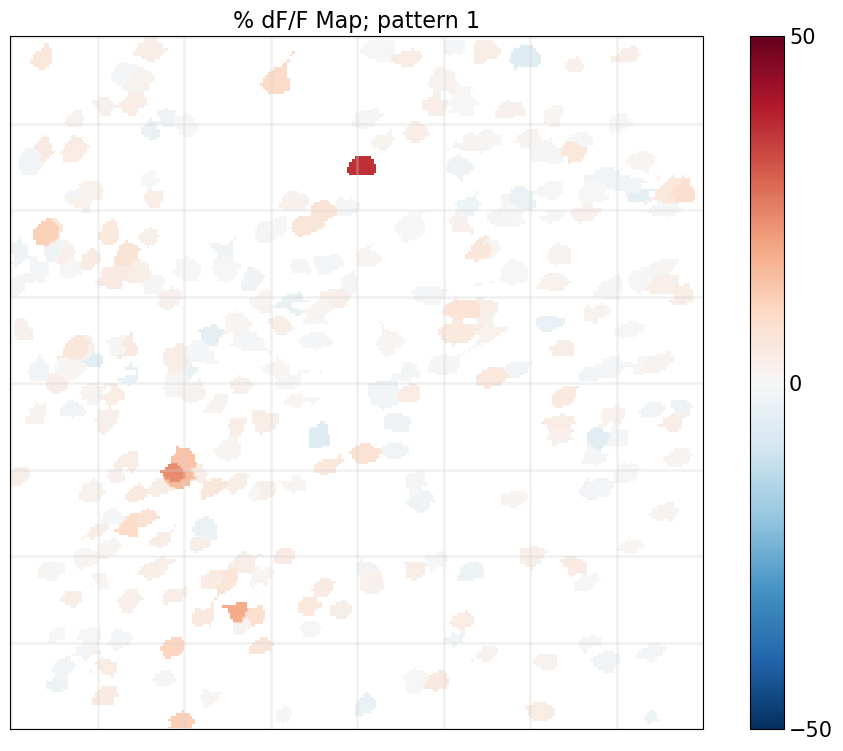

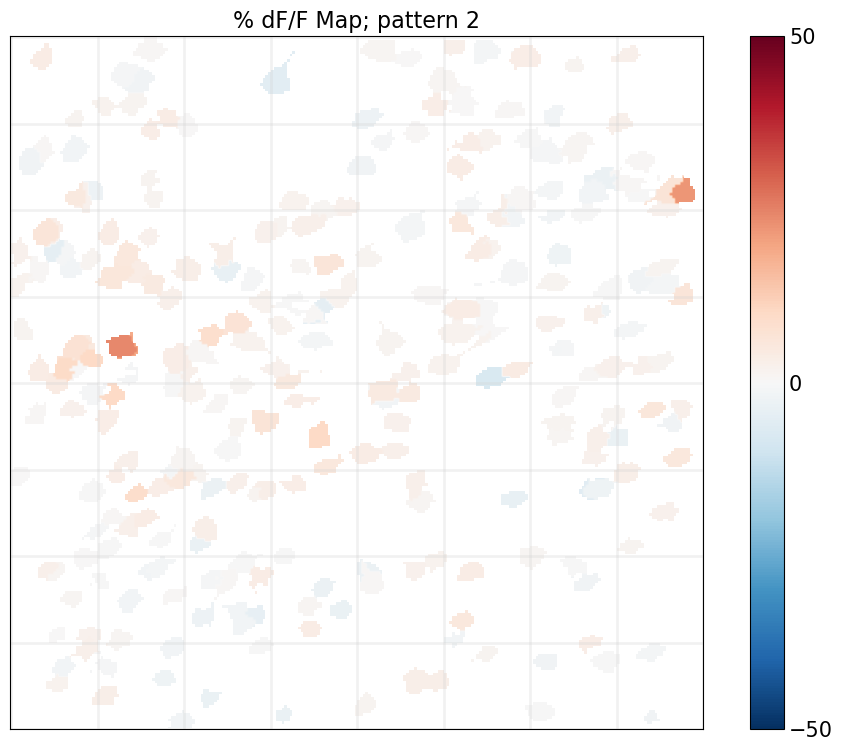

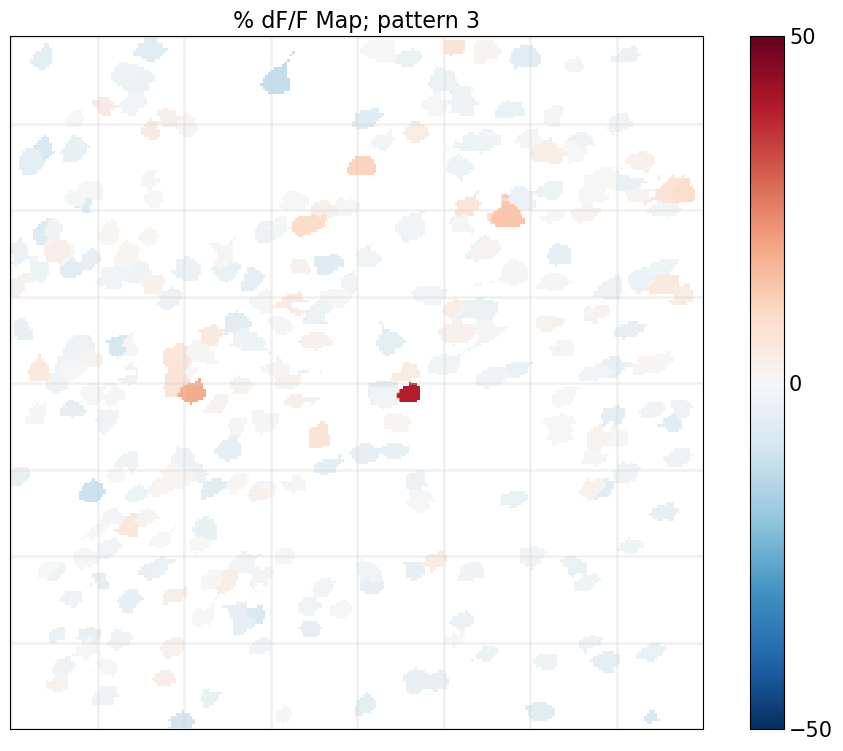

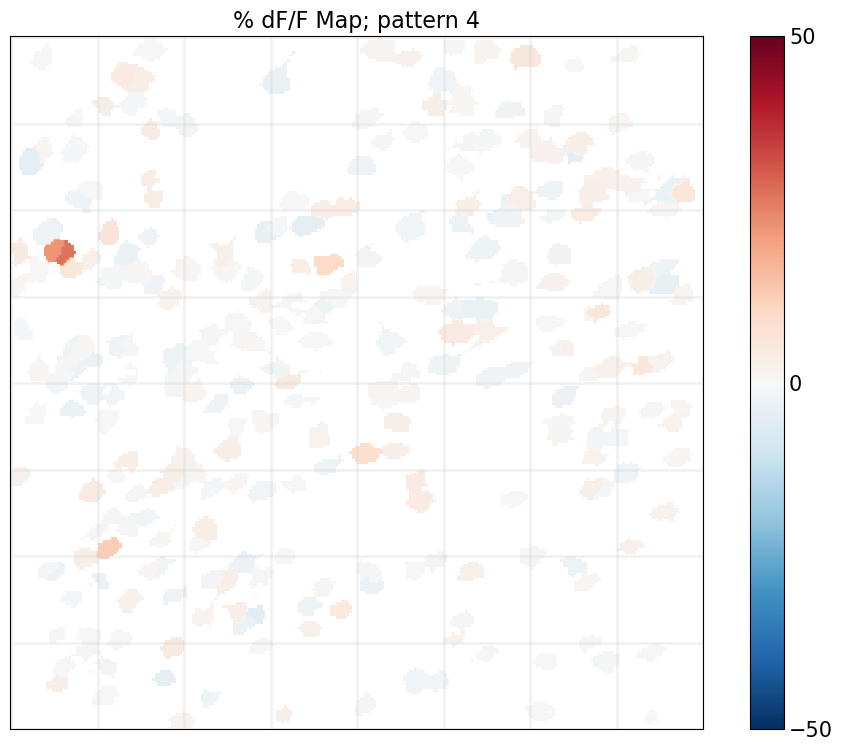

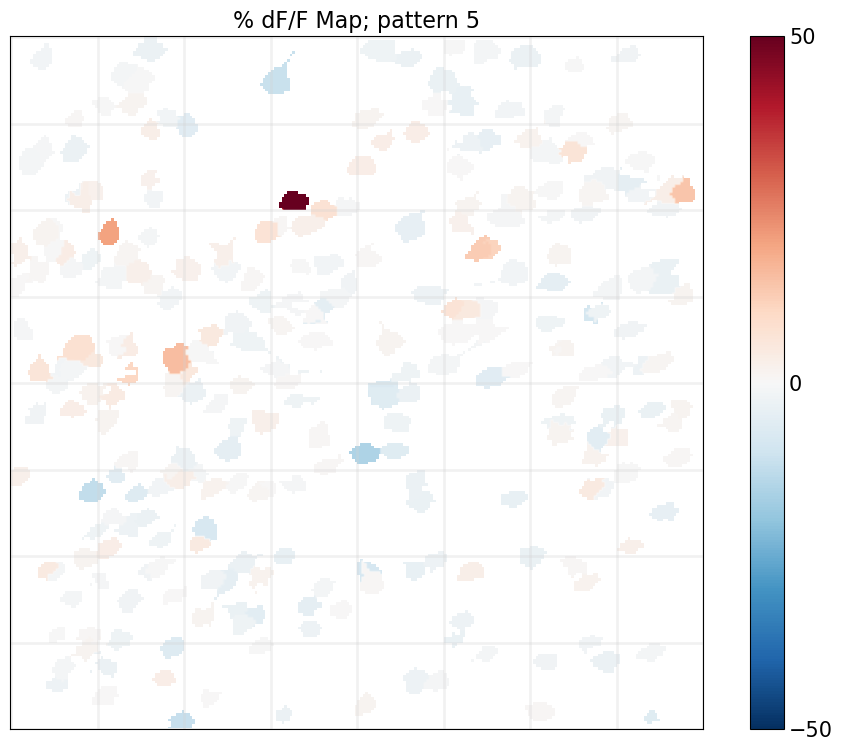

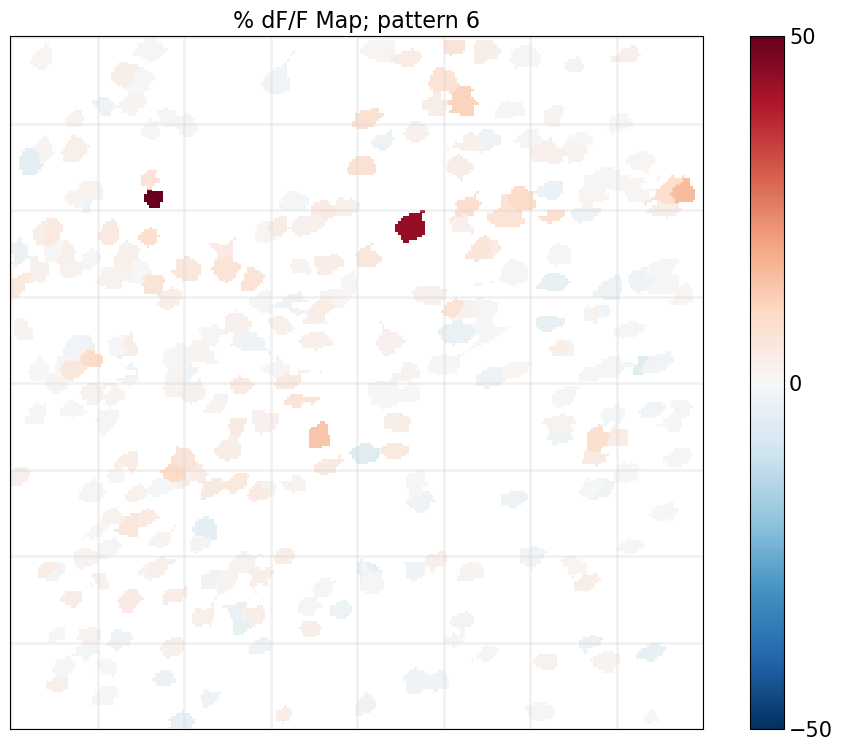

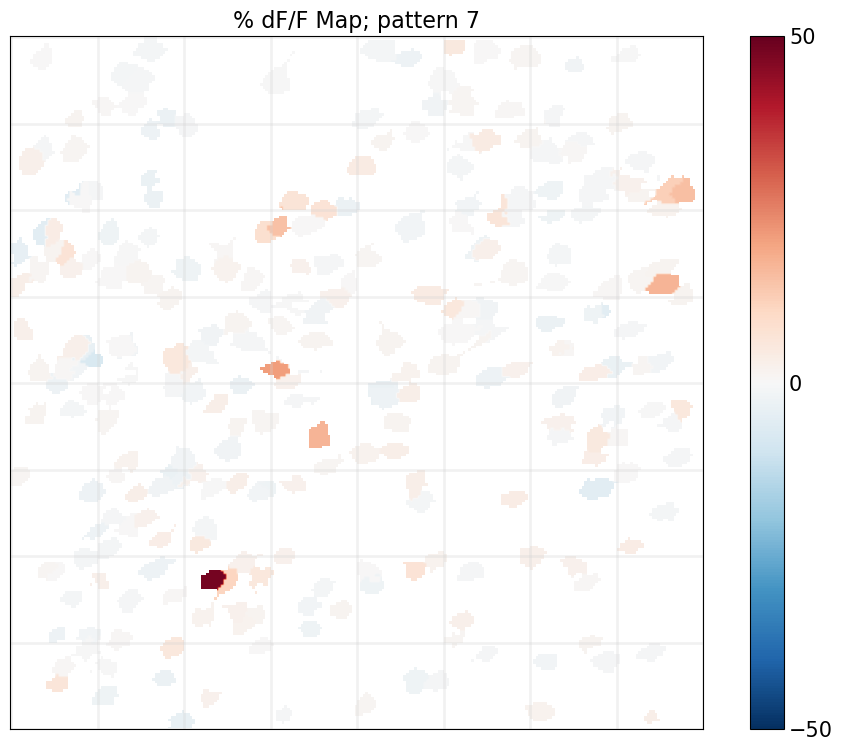

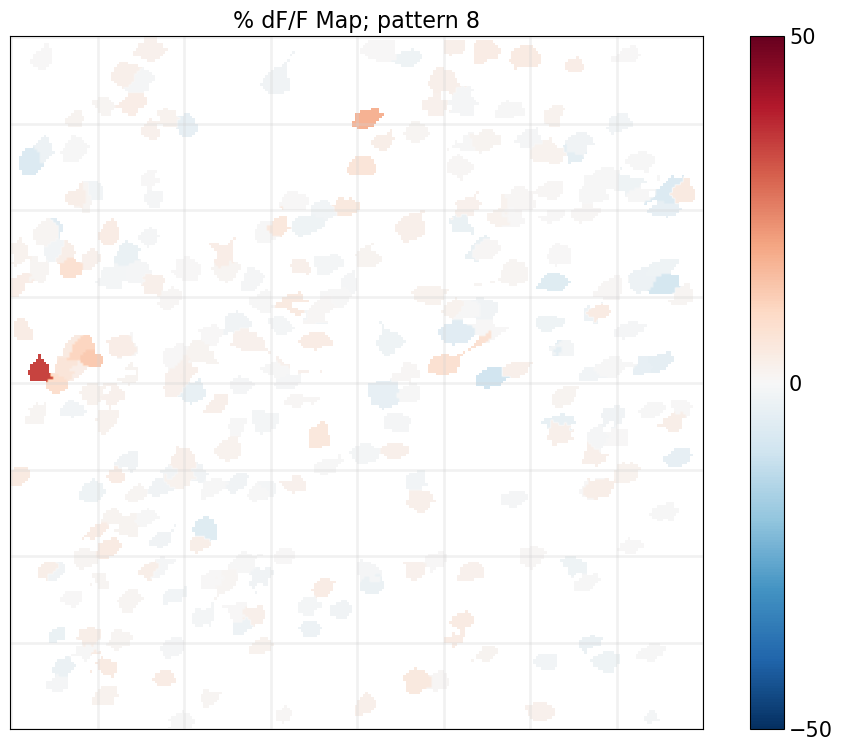

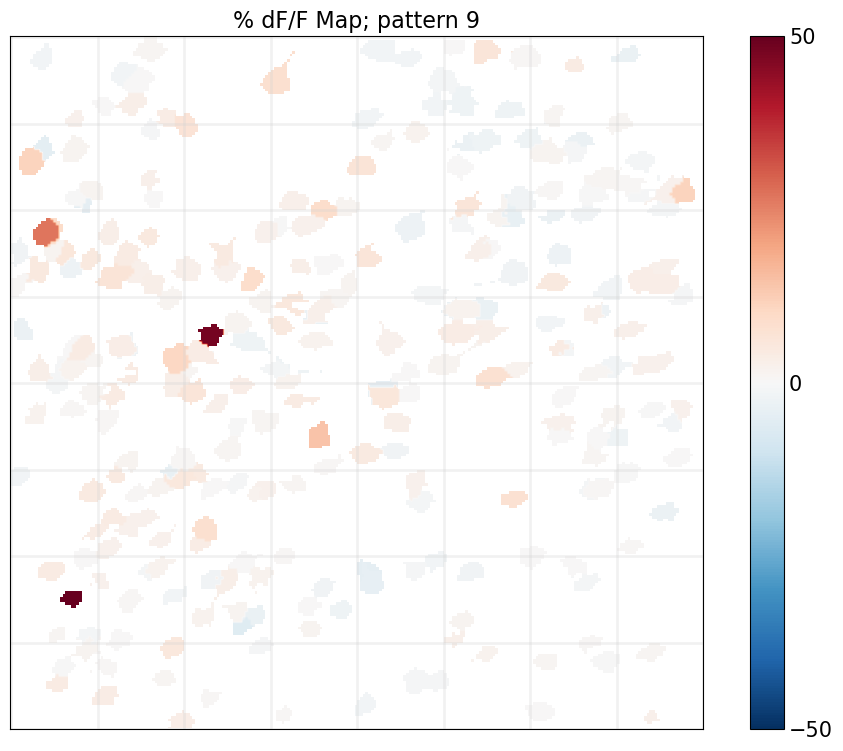

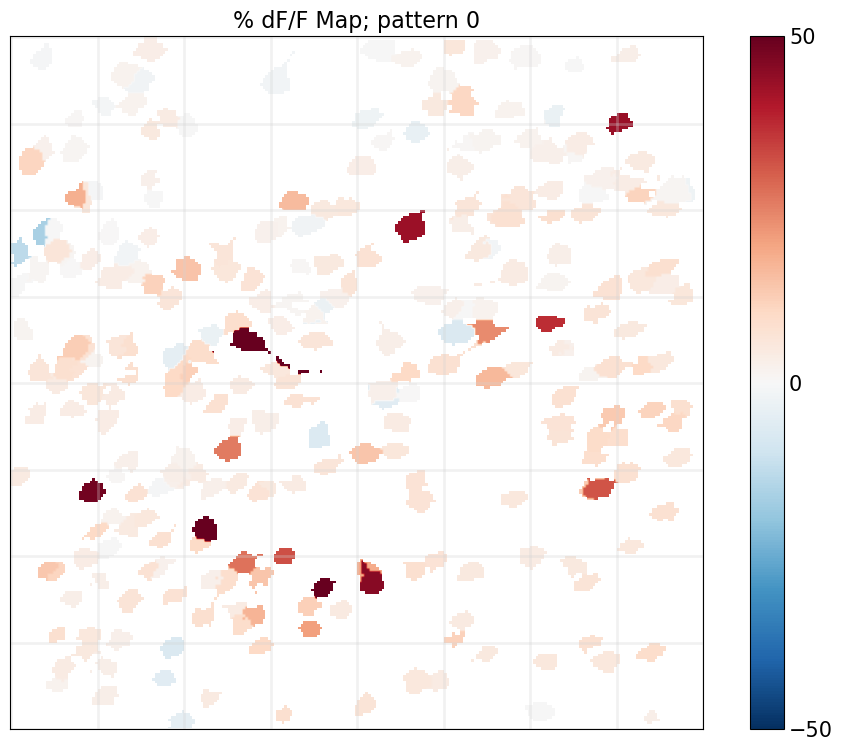

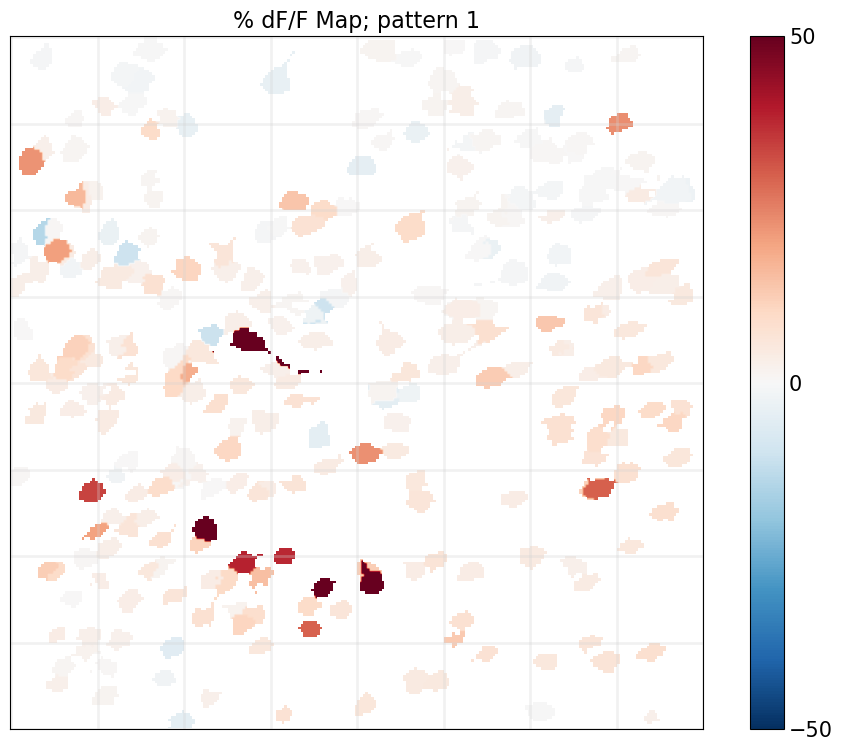

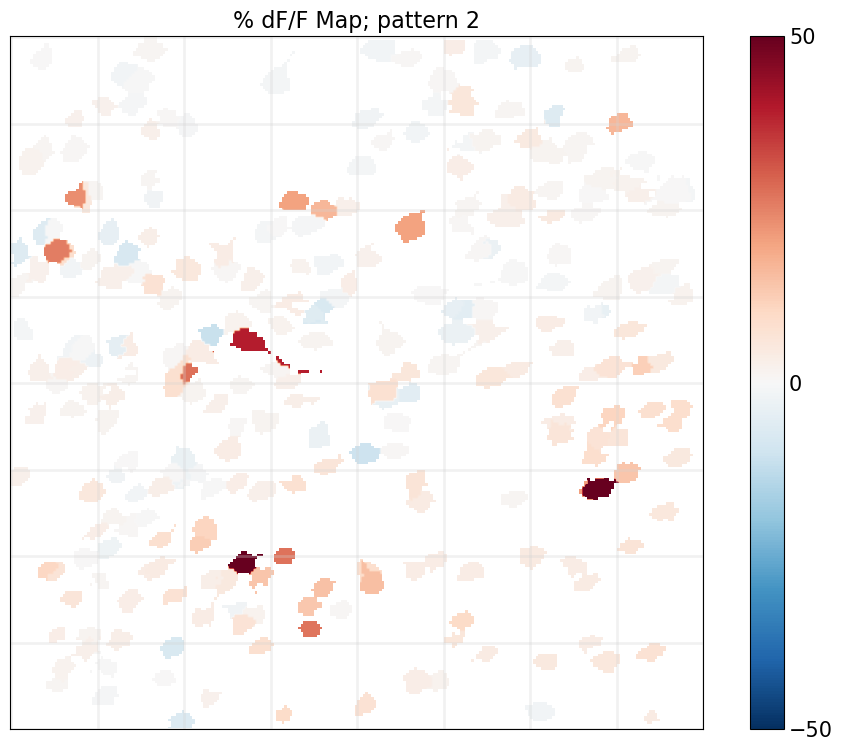

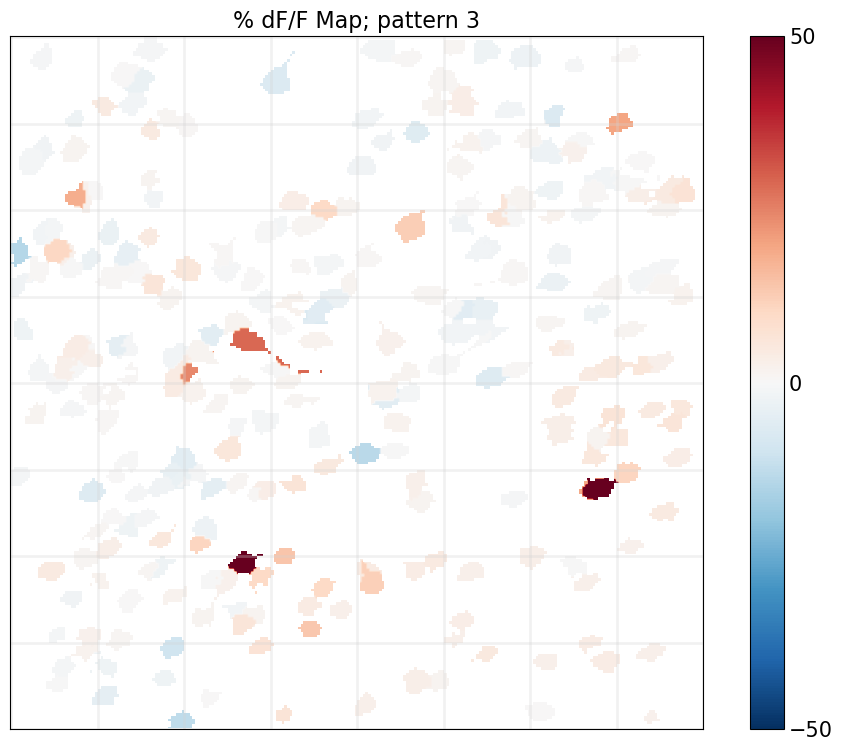

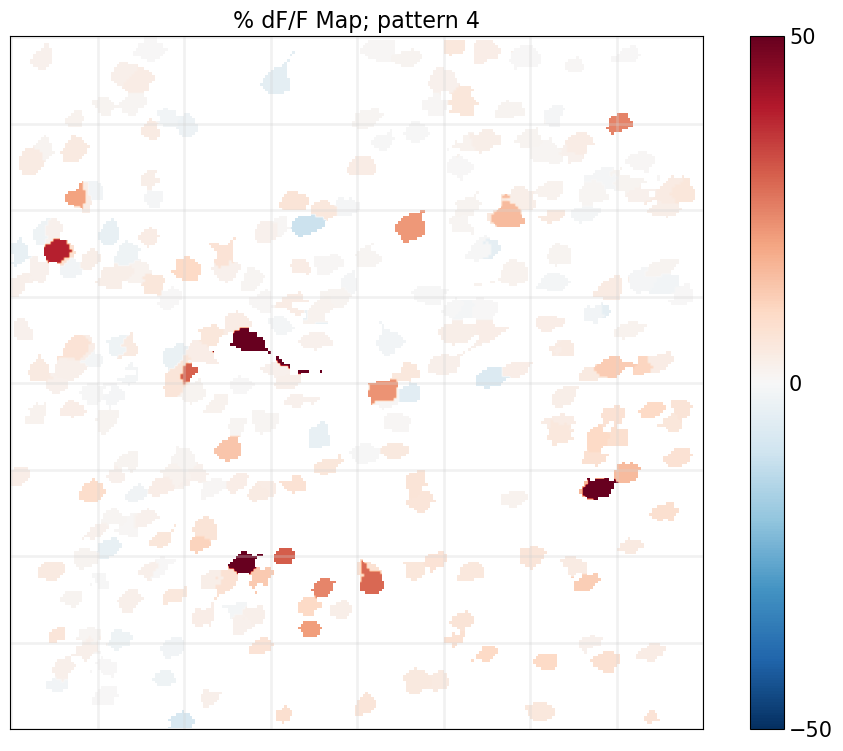

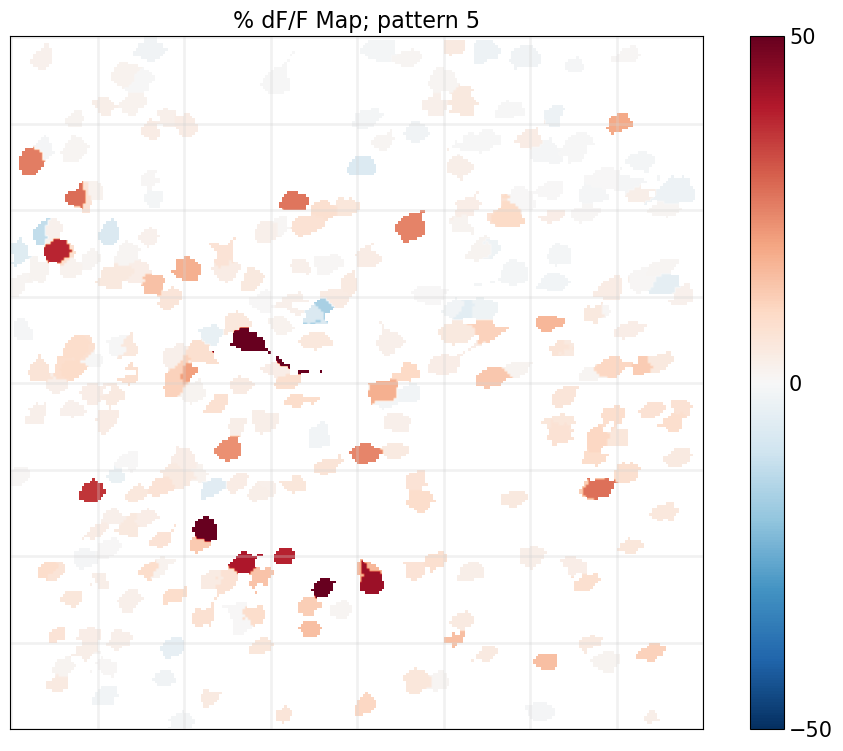

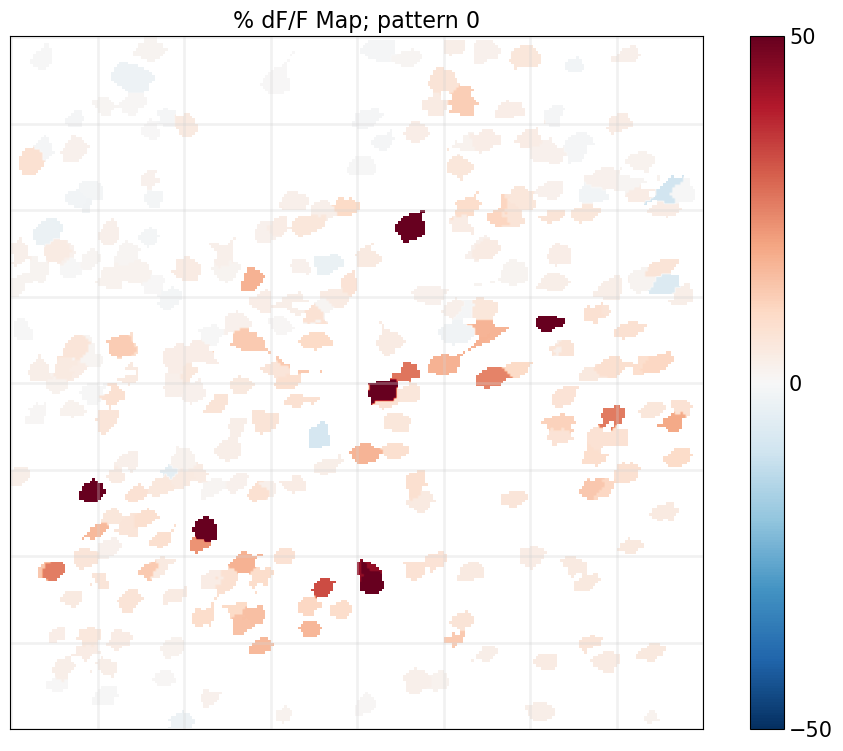

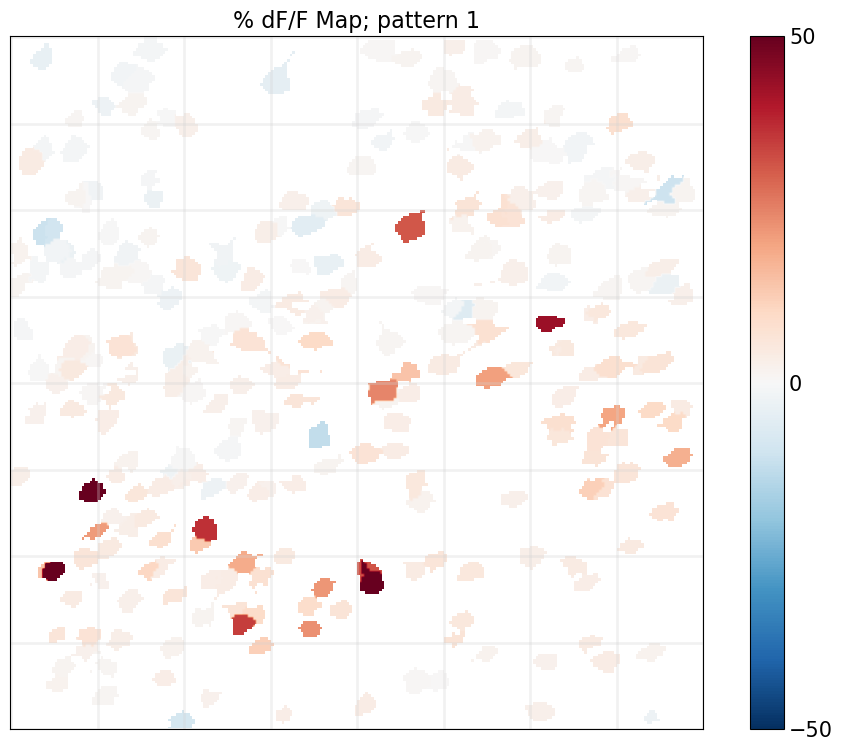

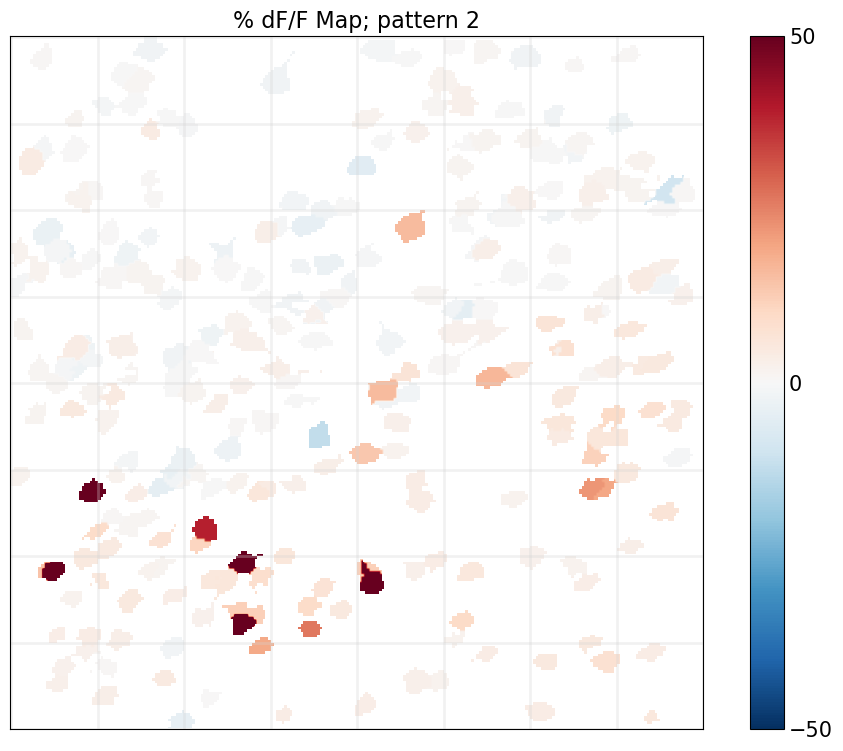

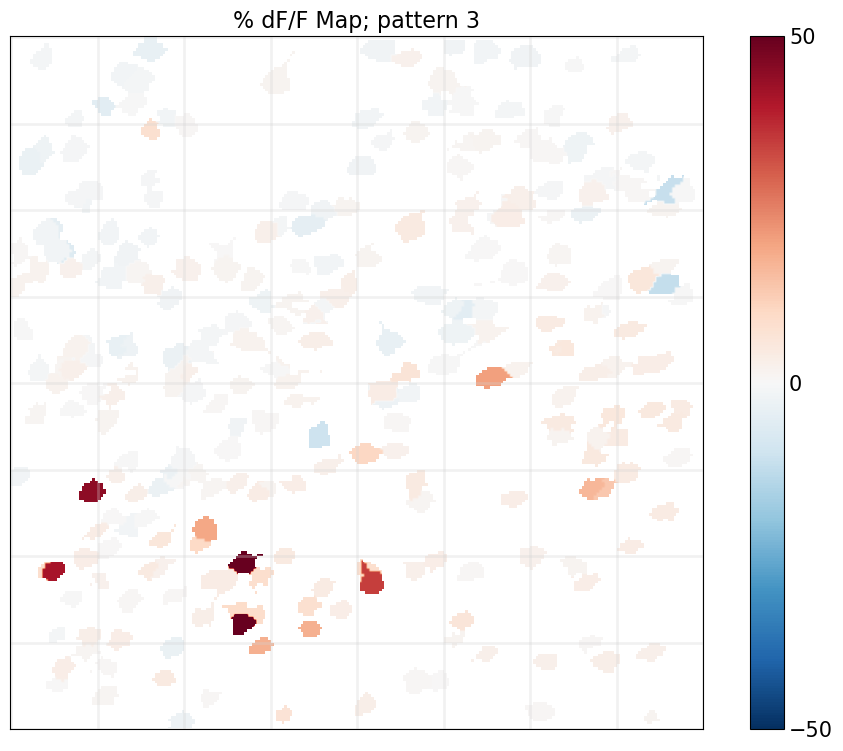

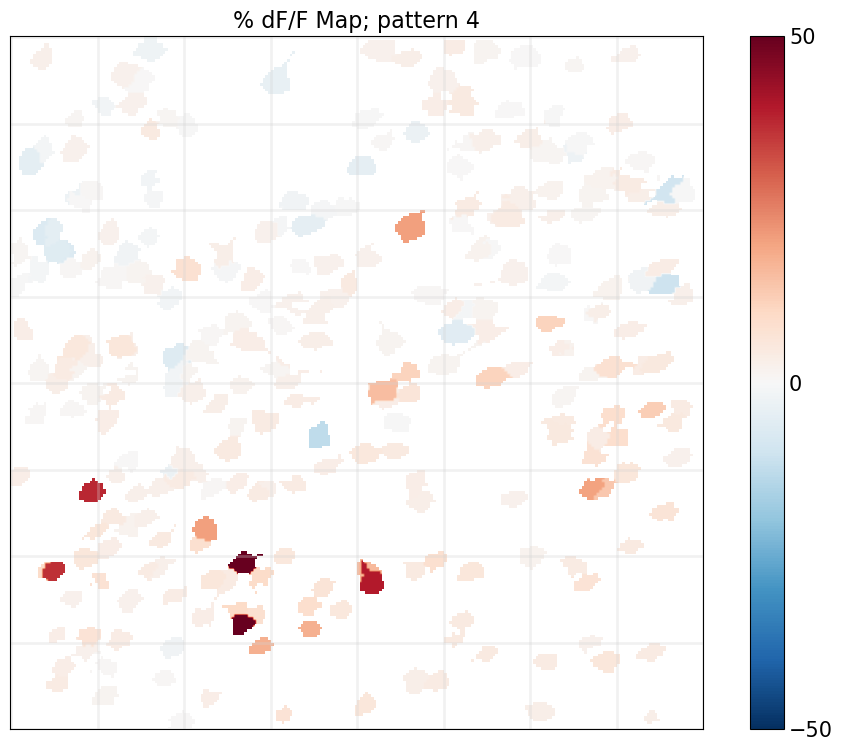

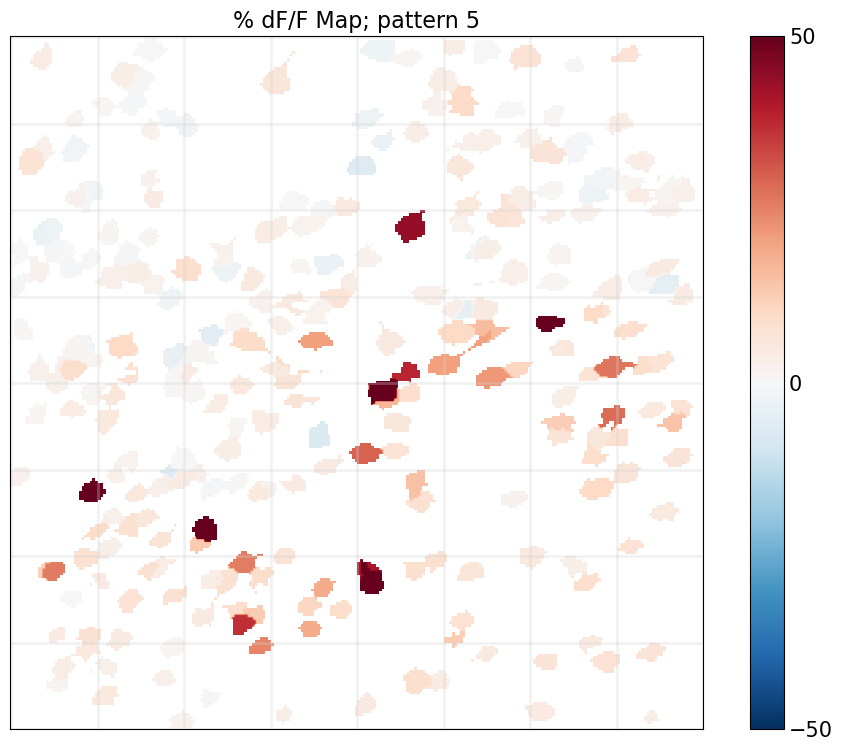

In [19]:
with qcsf.analysis_2p_general(file_path=file_path_root,expt_params=exp_params) as qapg:
    avgTrial_cell_pre, trial_dfoFtrace_pre, df2P_cell_pre, dfoF2P_cell_pre, dfV_cell_pre, dfoFV_cell_pre= qapg.generate_dfof_quiet(trial_ftrace_pre,mwf_pre,iTrialVis,iTrial2P,nStimFr_cut=7, n2PRespFr=6)
    avgTrial_cell_post, trial_dfoFtrace_post, df2P_cell_post, dfoF2P_cell_post, dfV_cell_post, dfoFV_cell_post= qapg.generate_dfof_quiet(trial_ftrace_post,mwf_post,iTrialVis,iTrial2P,nStimFr_cut=7, n2PRespFr=6)
    
    dFoF_map_cell_masksV_pre,dFoF_map_maskV_pre = qapg.generate_dfof_map_cell(im_aip_pre,cell_masks,dfoFV_cell_pre)
    dFoF_map_cell_masksV_post,dFoF_map_maskV_post = qapg.generate_dfof_map_cell(im_aip_post,cell_masks,dfoFV_cell_post)

    dFoF_map_cell_masks2P_pre,dFoF_map_mask2P_pre = qapg.generate_dfof_map_cell(im_aip_pre,cell_masks,dfoF2P_cell_pre)
    dFoF_map_cell_masks2P_post,dFoF_map_mask2P_post = qapg.generate_dfof_map_cell(im_aip_post,cell_masks,dfoF2P_cell_post)

    # uncomment to see the plots
    #qapg.plot_dfof_map_cell(dFoF_map_mask2P_pre,color_lim=50)
    #qapg.plot_dfof_map_cell(dFoF_map_mask2P_post,color_lim=50)
    #qapg.plot_dfof_map_cell(dFoF_map_maskV_pre,color_lim=50)
    #qapg.plot_dfof_map_cell(dFoF_map_maskV_post,color_lim=50)

print("done at" , datetime.now().time())

### Check that cell mask maps reflect pixel maps

In [ ]:
nOris = dFoF_map_maskV_pre.shape[0]; nrows = int(nOris/2); ncols = int(nOris/nrows); cl = 50
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8, 6));font = {'size'   : 10}; mpl.rc('font', **font)
axs = axs.flatten(); fig.subplots_adjust(right=0.9) #for colorbar room

for i,ax in zip(range(nOris),axs):
    im = np.hstack((dfoFsmooth_V_pre[i,:,:],dFoF_map_maskV_pre[i,:,:]))
    im1 = ax.imshow(im, vmin=-cl, vmax=cl, cmap='RdBu_r')
    ax.axis('off')
    ax.set_title(str(i*30)+'°')

cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(im1, cax=cbar_ax).outline.set_visible(False) or cbar_ax.tick_params(size=0) or cbar_ax.yaxis.set_ticks([-cl, cl])
plt.subplots_adjust(wspace=0.01, hspace=0.25)

In [ ]:
nOris = dFoF_map_maskV_pre.shape[0]; nrows = int(nOris/2); ncols = int(nOris/nrows); cl = 50
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8, 6));font = {'size'   : 10}; mpl.rc('font', **font)
axs = axs.flatten(); fig.subplots_adjust(right=0.9) #for colorbar room

for i,ax in zip(range(nOris),axs):
    im = np.hstack((dfoFsmooth_V_post[i,:,:],dFoF_map_maskV_post[i,:,:]))
    im1 = ax.imshow(im, vmin=-cl, vmax=cl, cmap='RdBu_r')
    ax.axis('off')
    ax.set_title(str(i*30)+'°')

cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(im1, cax=cbar_ax).outline.set_visible(False) or cbar_ax.tick_params(size=0) or cbar_ax.yaxis.set_ticks([-cl, cl])
plt.subplots_adjust(wspace=0.01, hspace=0.25)

### smooth

In [23]:
trialavg_dfoF_trace2P_pre = trial_dfoFtrace_pre[:,iTrial2P,:] #all cells, 2P trials, all reps
trialavg_dfoF_traceV_pre = trial_dfoFtrace_pre[:,iTrialVis,:] #all cells, vis trials, all reps
with qcsf.analysis_vis_and_other(file_path=file_path_root,vis_oth_params=exp_params) as qa2p:
    dfoF_trace_lowessV_pre = qa2p.smoothWithLowess(trialavg_dfoF_traceV_pre)
    dfoF_trace_lowess2P_pre = qa2p.smoothWithLowess(trialavg_dfoF_trace2P_pre)
print("done at" , datetime.now().time())

Smoothing data with Lowess filter...
Smoothing stim 0.

IndexError: index 245 is out of bounds for axis 0 with size 245

In [24]:
trialavg_dfoF_trace2P_post = trial_dfoFtrace_post[:,iTrial2P,:] #all cells, 2P trials, all reps
trialavg_dfoF_traceV_post = trial_dfoFtrace_post[:,iTrialVis,:] #all cells, vis trials, all reps
with qcsf.analysis_vis_and_other(file_path=file_path_root,vis_oth_params=exp_params) as qa2p:
    dfoF_trace_lowessV_post = qa2p.smoothWithLowess(trialavg_dfoF_traceV_post)
    dfoF_trace_lowess2P_post = qa2p.smoothWithLowess(trialavg_dfoF_trace2P_post)
print("done at" , datetime.now().time())

Smoothing data with Lowess filter...
Smoothing stim 0.

IndexError: index 245 is out of bounds for axis 0 with size 245

### simplify vals to single scalar

In [25]:
dfoF_V_avg_array_pre = dfoF_trace_lowessV_pre[:, :, br[1]:br[1]+exp_params['nStimFrV']].max(axis=2)
dfoF_2P_avg_array_pre = dfoF_trace_lowess2P_pre[:, :, br[1]+9:br[1]+9+6].max(axis=2)
dfoF_V_avg_array_post = dfoF_trace_lowessV_post[:, :, br[1]:br[1]+exp_params['nStimFrV']].max(axis=2)
dfoF_2P_avg_array_post = dfoF_trace_lowess2P_post[:, :, br[1]+9:br[1]+9+6].max(axis=2)

dfoFV_cell_pre_argmax = np.argmax(np.abs(dfoF_V_avg_array_pre), axis=1)
dfoFV_cell_post_argmax = np.argmax(np.abs(dfoF_V_avg_array_post), axis=1)

preferredV_pre_abs = np.take(dfoFV_cell_pre,dfoFV_cell_pre_argmax)
preferredV_post_abs = np.take(dfoFV_cell_post,dfoFV_cell_post_argmax)

preferredV_pre = dfoF_V_avg_array_pre.max(axis=1)
preferred2P_pre = dfoF_2P_avg_array_pre.max(axis=1)
preferredV_post = dfoF_V_avg_array_post.max(axis=1)
preferred2P_post = dfoF_2P_avg_array_post.max(axis=1)

preferredV_stimd_pre = preferredV_pre[stim_iC]
preferred2P_stimd_pre = preferred2P_pre[stim_iC]
preferredV_stimd_post = preferredV_post[stim_iC]
preferred2P_stimd_post = preferred2P_post[stim_iC]

preferredV_quiet_pre = preferredV_pre[stim_iC_manip]
preferred2P_quiet_pre = preferred2P_pre[stim_iC_manip]
preferredV_quiet_post = preferredV_post[stim_iC_manip]
preferred2P_quiet_post = preferred2P_post[stim_iC_manip]

NameError: name 'dfoF_trace_lowessV_pre' is not defined

## plots

In [39]:
from scipy.linalg import lstsq

In [40]:
M = np.transpose(np.array([np.ones(len(preferredV_stimd_pre)), preferredV_stimd_pre]))
p, res, rnk, s = lstsq(M, preferredV_stimd_post)
print(p)

[5.23435242 0.62111732]


# Worksh

In [ ]:
# here is a workspace that will still be easily accessible when all other drop downs are collapsed